In [107]:
from dotenv import load_dotenv
load_dotenv()

True

In [108]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(model="llama-3.1-8b-instant", model_provider="groq")
# llm = init_chat_model(model="gemma-3-27b-it", model_provider="google_genai")

In [109]:
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

    category: str
    priority: str
    issue_analyzer_confidence: float
    sentiment: float

In [110]:
from pydantic import BaseModel, Field, model_validator
from langchain_core.output_parsers import PydanticOutputParser

class IssueExtractionResult(BaseModel):
    category: str = Field(
        description="Categorize the issue: Billing, Technical, Login, or General.",
        default="General"
    )
    priority: str = Field(
        description="Assess priority: Low, Medium, High, or Urgent.",
        default="Low"
    )
    confidence: float = Field(
        description="A score from 0.0 to 1.0 indicating how confident you are in this classification. A vague message should have a low score.", 
        ge=0.0, 
        le=1.0,
        default=0.0
    )
    sentiment_score: float = Field(
        description="A score from -1.0 (extremely negative/angry) to 1.0 (extremely positive/happy). 0.0 is neutral.",
        default=0.0
    )

    # The Dynamic Validator
    @model_validator(mode='before')
    @classmethod
    def drop_empty_strings(cls, data: any) -> any:
        """
        Scans the incoming JSON dictionary. If any string is empty or just spaces,
        it removes the key entirely, forcing Pydantic to use the field's default value.
        """
        # Ensure the incoming data is actually a dictionary
        if isinstance(data, dict):
            cleaned_data = {}
            for key, value in data.items():
                # If it's a string and it's empty/blank, we skip adding it to our clean dict
                if isinstance(value, str) and not value.strip():
                    continue 
                # Otherwise, keep the data
                cleaned_data[key] = value
            return cleaned_data
        return data

issue_extraction_parser = PydanticOutputParser(pydantic_object=IssueExtractionResult)
print(issue_extraction_parser.get_format_instructions())

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"category": {"default": "General", "description": "Categorize the issue: Billing, Technical, Login, or General.", "title": "Category", "type": "string"}, "priority": {"default": "Low", "description": "Assess priority: Low, Medium, High, or Urgent.", "title": "Priority", "type": "string"}, "confidence": {"default": 0.0, "description": "A score from 0.0 to 1.0 indicating how confident you are in this classification. A vague message should have a low score.", "maximum": 1.0, "minimum": 0.0, "title": "Confidence", "type": "number"}

In [111]:
from langchain_core.prompts import PromptTemplate

def analyze_issue(state: AgentState):
    latest_message = state["messages"][-1].content

    prompt = PromptTemplate(
        template="""
            You are a strict data extraction algorithm."
            Analyze the user's message and extract the exact fields requested.
                  
            {format_instructions}
            
            User Message: {message}
        """,
        input_variables=["message"],
        partial_variables={"format_instructions": issue_extraction_parser.get_format_instructions()}
    )

    analyzer_chain = prompt | llm | issue_extraction_parser

    try:
        result = analyzer_chain.invoke({"message": latest_message})
        print(f"[analyze_issue] {result}")
        print(f"[analyze_issue] {type(result)}")
    except Exception as e:
        print(f"[analyze_issue] [ERROR] {e}")
        result = IssueExtractionResult()
    
    return {
        "category": result.category,
        "priority": result.priority,
        "issue_analyzer_confidence": result.confidence,
        "sentiment": result.sentiment_score
    }


In [112]:
from typing import Literal

def get_sentiment(sentiment_score: float) -> Literal["Angry", "Frustrated", "Neutral", "Satisfied", "Happy"]:
    score = max(-1.0, min(1.0, sentiment_score))
    
    if score <= -0.6:
        return "Angry"
    elif score <= -0.2:
        return "Frustrated"
    elif score < 0.2:
        return "Neutral"
    elif score < 0.6:
        return "Satisfied"
    else:
        return "Happy"

In [117]:
from langchain_core.messages import SystemMessage

def generate_reply(state: AgentState):
    default_issue_analize_result = IssueExtractionResult()
    category = state.get("category", default_issue_analize_result.category)
    priority = state.get("priority", default_issue_analize_result.priority)
    sentiment_score = state.get("sentiment_score", default_issue_analize_result.sentiment_score)
    sentiment = get_sentiment(sentiment_score)

    sys_prompt = f"""You are a world-class, empathetic customer support agent.
    
    CURRENT TICKET CONTEXT:
    - Issue Category: {category}
    - Priority Level: {priority}
    - User's Current Emotion: {sentiment}
    
    YOUR INSTRUCTIONS:
    1. Acknowledge their issue directly based on the '{category}'.
    2. Adjust your tone perfectly to match their '{sentiment}' emotion. 
       - If they are 'Angry' or 'Frustrated', be deeply apologetic, highly professional, and concise. Get straight to the point.
       - If they are 'Neutral' 'Satisfied' or 'Happy', be warm, conversational, and friendly.
    3. IMPORTANT: Do NOT explicitly mention the category, priority or emotion. Just naturally embody the correct tone.
    """

    messages = [SystemMessage(content=sys_prompt)] + state["messages"]

    response = llm.invoke(messages)
    return {"messages": [response]}

In [118]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

workflow.add_node("analyze_issue", analyze_issue)
workflow.add_node("generate_reply", generate_reply)

workflow.add_edge(START, "analyze_issue")
workflow.add_edge("analyze_issue", "generate_reply")
workflow.add_edge("generate_reply", END)

graph = workflow.compile()

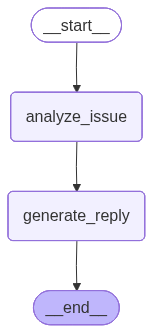

In [119]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [120]:
from langchain_core.messages import HumanMessage
from pprint import pprint

result = graph.invoke({"messages": [HumanMessage(content="Hello")]})
pprint(result)

[analyze_issue] category='General' priority='Low' confidence=0.0 sentiment_score=0.0
[analyze_issue] <class '__main__.IssueExtractionResult'>
{'category': 'General',
 'issue_analyzer_confidence': 0.0,
 'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='f58be1bc-24fb-4c2f-bd40-2a200720de72'),
              AIMessage(content="Hello! It's great to connect with you today. How can I help you with something? Is there something specific that's been on your mind, or are you just reaching out to say hello and see how things are going? I'm all ears and here to chat.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 198, 'total_tokens': 254, 'completion_time': 0.101299752, 'completion_tokens_details': None, 'prompt_time': 0.011320862, 'prompt_tokens_details': None, 'queue_time': 0.045311118, 'total_time': 0.112620614}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tie